<a href="https://colab.research.google.com/github/Zishaniitm/Codsoft-Internship-Projects/blob/main/Titanic_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TITANIC SURVIVAL PREDICTION**

Using the Titanic dataset to build a model that predicts whether a
passenger on the Titanic survived or not. This is a classic beginner
project with readily available data.
The dataset typically used for this project contains information
about individual passengers, such as their age, gender, ticket
class, fare, cabin, and whether or not they survived.

## **Step 1 - Understanding the Dataset**

In [102]:
#Importing the important libraries
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [103]:
#Loading the data
test_data = pd.read_csv('Titanic-Dataset.csv')
# Make all charts look clean
sb.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
print("Data Loaded Successfully")

Data Loaded Successfully


In [104]:
#Printing the shape of the dataset it shows how long is our table
print(f"Shape: {test_data.shape}")

Shape: (891, 12)


In [105]:
#Head of the dataset
test_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [106]:
#Tail of the dataset
test_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [107]:
#Overview of the 5 random columns from the dataset
test_data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.0500,NaN,S
685,686,0,2,"Laroche, Mr. Joseph Philippe Lemercier",male,25.0,1,2,SC/Paris 2123,41.5792,NaN,C
645,646,1,1,"Harper, Mr. Henry Sleeper",male,48.0,1,0,PC 17572,76.7292,D33,C
575,576,0,3,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
360,361,0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S


In [108]:
#Getting the info about the data
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [109]:
#Obtaining the stastical analysis of the data
test_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [110]:
#counting the missing values
test_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [111]:
#mising values by percentage
print("\nMissing %:")
print(round(test_data.isnull().sum() / len(test_data) * 100, 2))


Missing %:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [112]:
# How many survived vs didn't?
print(test_data['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [113]:
# How many passengers per class?
print(test_data['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [114]:
# What genders are in the data?
print(test_data['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [115]:
# What ports did people board from?
print(test_data['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


# **Step 2- Exploratory Data Analysis(EDA)**
# The big idea behind EDA
Before training any model, you need to answer one question: "Which features actually affect survival?" EDA is how you answer it — with charts and numbers, not guesswork.

In [116]:
# Make all charts look clean
sb.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

/tmp/ipykernel_5082/807192504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='Survived', data=test_data, palette=['#E74C3C', '#2ECC71'])


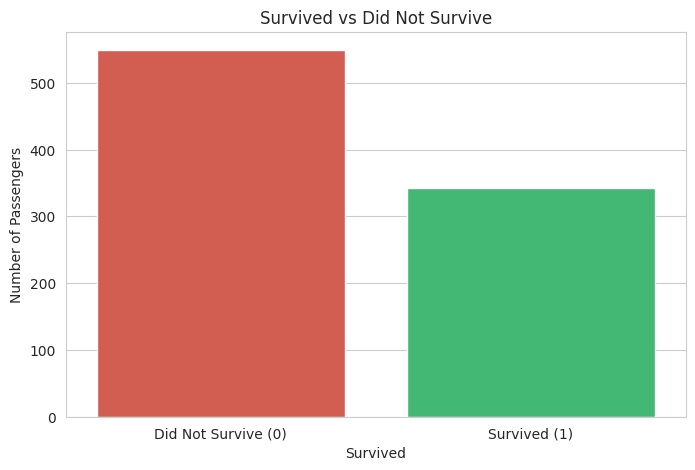

Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


In [117]:
#Chart 1 Overall Survival Count
sb.countplot(x='Survived', data=test_data, palette=['#E74C3C', '#2ECC71'])
plt.title('Survived vs Did Not Survive')
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])
plt.ylabel('Number of Passengers')
plt.show()

# Also print exact numbers
print(test_data['Survived'].value_counts())
print(f"\nSurvival rate: {test_data['Survived'].mean()*100:.1f}%")

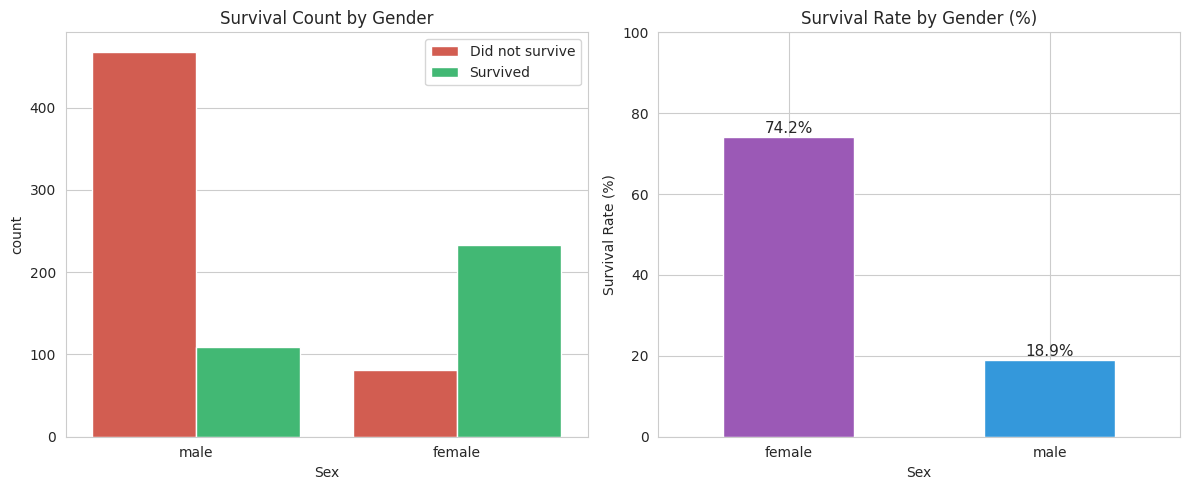

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [118]:
#Chart 2 — Survival by Gender (most important!)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 2a: Count of survivors by gender
sb.countplot(x='Sex', hue='Survived', data=test_data,
              palette={0:'#E74C3C', 1:'#2ECC71'}, ax=axes[0])
axes[0].set_title('Survival Count by Gender')
axes[0].legend(['Did not survive', 'Survived'])

# Chart 2b: Survival RATE by gender (more meaningful)
survival_by_sex = test_data.groupby('Sex')['Survived'].mean() * 100
survival_by_sex.plot(kind='bar', color=['#9B59B6', '#3498DB'],
                     ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Gender (%)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(test_data.groupby('Sex')['Survived'].mean() * 100)

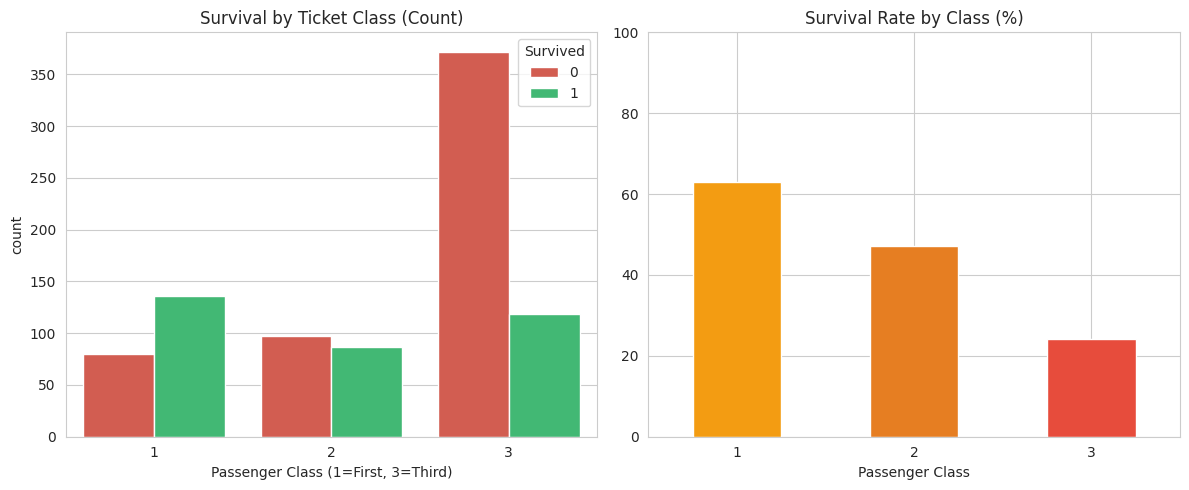

In [119]:
#Chart 3 — Survival by Ticket Class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sb.countplot(x='Pclass', hue='Survived', data=test_data,
              palette={0:'#E74C3C', 1:'#2ECC71'}, ax=axes[0])
axes[0].set_title('Survival by Ticket Class (Count)')
axes[0].set_xlabel('Passenger Class (1=First, 3=Third)')

survival_by_class = test_data.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar', color=['#F39C12','#E67E22','#E74C3C'],
                       ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Class (%)')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Passenger Class')

plt.tight_layout()
plt.show()

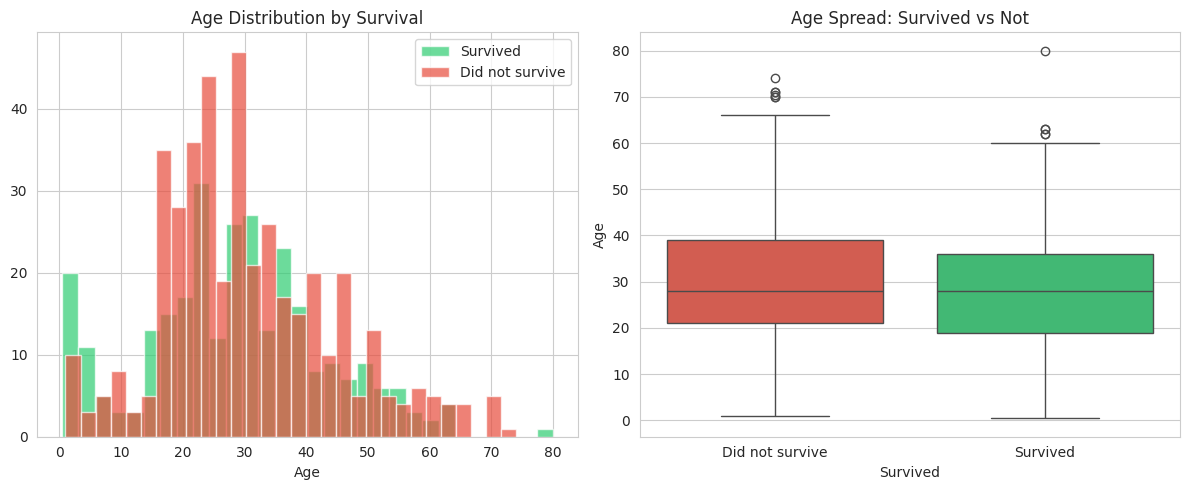

Missing Age values: 177
Mean age of survivors: 28.3
Mean age of non-survivors: 30.6


In [120]:
#Chart 4 — Age distribution (and where data is missing)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution for survivors vs non-survivors
test_data[test_data['Survived']==1]['Age'].dropna().hist(bins=30, alpha=0.7,
    color='#2ECC71', label='Survived', ax=axes[0])
test_data[test_data['Survived']==0]['Age'].dropna().hist(bins=30, alpha=0.7,
    color='#E74C3C', label='Did not survive', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot — shows median and spread clearly
sb.boxplot(x=test_data['Survived'].astype(str), y='Age', data=test_data,
            hue=test_data['Survived'].astype(str),
            palette={'0':'#E74C3C', '1':'#2ECC71'}, ax=axes[1], legend=False)
axes[1].set_title('Age Spread: Survived vs Not')
axes[1].set_xticks([0, 1]) # Explicitly set tick locations
axes[1].set_xticklabels(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

print(f"Missing Age values: {test_data['Age'].isnull().sum()}")
print(f"Mean age of survivors: {test_data[test_data['Survived']==1]['Age'].mean():.1f}")
print(f"Mean age of non-survivors: {test_data[test_data['Survived']==0]['Age'].mean():.1f}")

A histogram shows the shape of data. A boxplot shows median, spread, and outliers.

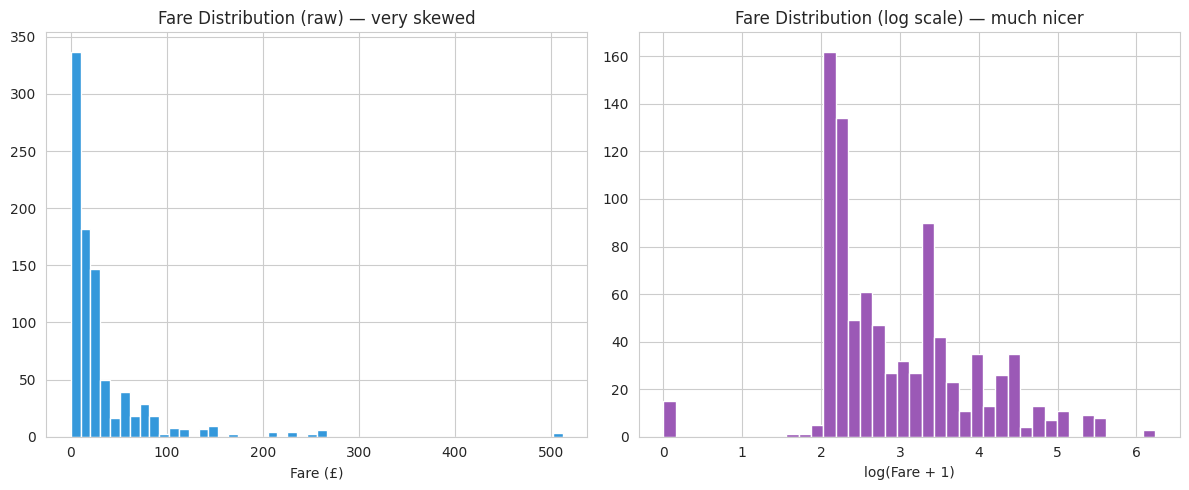

In [121]:
#Chart 5 — Fare distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw Fare — very skewed (most paid low, few paid very high)
test_data['Fare'].hist(bins=50, color='#3498DB', ax=axes[0])
axes[0].set_title('Fare Distribution (raw) — very skewed')
axes[0].set_xlabel('Fare (£)')

# Log transform makes it easier to see patterns
np.log1p(test_data['Fare']).hist(bins=40, color='#9B59B6', ax=axes[1])
axes[1].set_title('Fare Distribution (log scale) — much nicer')
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()

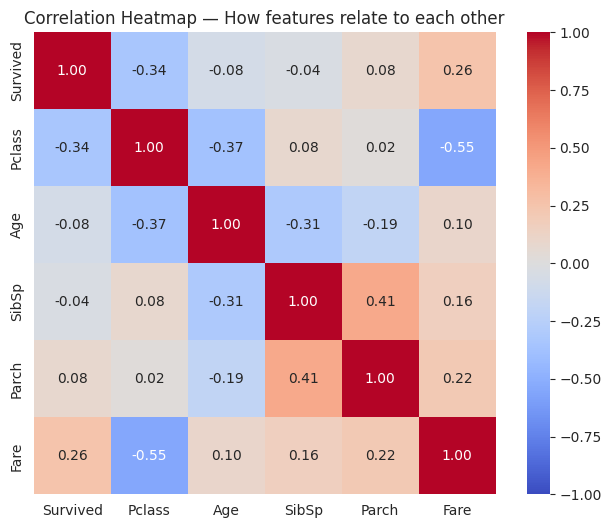

In [122]:
#Chart 6 — The correlation heatmap (overview of everything)
# Only works with numeric columns
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(8, 6))
correlation_matrix = test_data[numeric_cols].corr()

sb.heatmap(correlation_matrix,
            annot=True,          # Show the numbers inside each cell
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # Blue = negative, Red = positive correlation
            vmin=-1, vmax=1,
            square=True)

plt.title('Correlation Heatmap — How features relate to each other')
plt.show()

A correlation of +1 means "when X goes up, Y goes up." A correlation of -1 means the opposite. A correlation near 0 means no relationship. From this heatmap you'll see:

**Pclass** and **Survived** have a negative correlation (higher class number = lower survival)

**Fare** and **Survived** have a positive correlation (higher fare = higher survival)

**Pclass** and **Fare** are strongly negatively correlated (because class 1 is expensive — they basically measure the same thing)

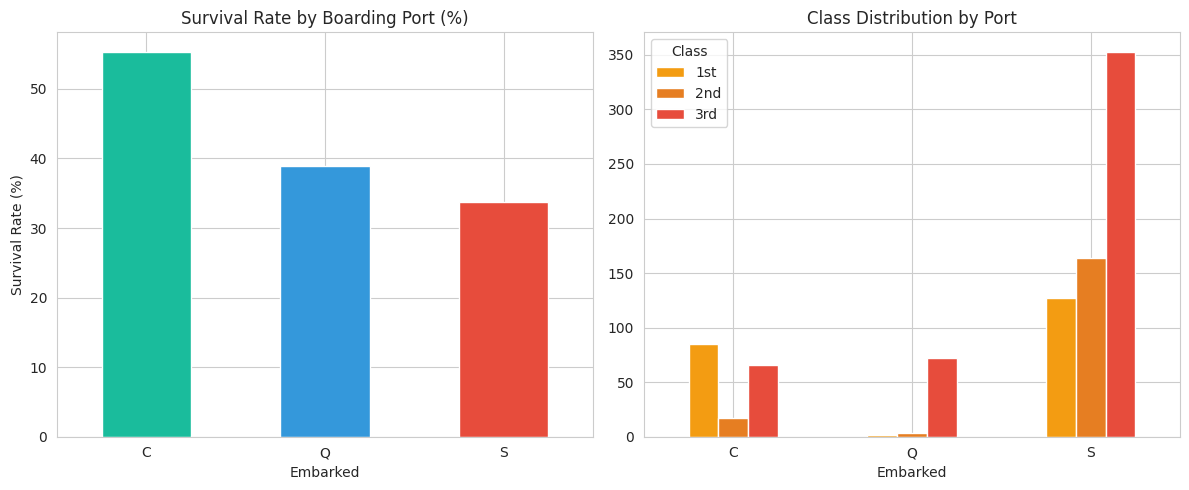

In [123]:
#Chart 7 — Survival by Embarked port
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survival_by_embarked = test_data.groupby('Embarked')['Survived'].mean() * 100
survival_by_embarked.plot(kind='bar', color=['#1ABC9C','#3498DB','#E74C3C'],
                           ax=axes[0], rot=0)
axes[0].set_title('Survival Rate by Boarding Port (%)')
axes[0].set_ylabel('Survival Rate (%)')

# Now check WHY — look at class distribution by port
pclass_by_embarked = test_data.groupby(['Embarked','Pclass']).size().unstack()
pclass_by_embarked.plot(kind='bar', ax=axes[1], rot=0,
                         color=['#F39C12','#E67E22','#E74C3C'])
axes[1].set_title('Class Distribution by Port')
axes[1].legend(['1st','2nd','3rd'], title='Class')

plt.tight_layout()
plt.show()

This is the detective moment — you'll see that Cherbourg has high survival because it had more 1st class passengers. The port itself didn't save anyone. This is called understanding causation vs correlation.

**After running all of this, you should be able to answer:**

Which single feature most affects survival? (Sex)

What percentage of 1st class passengers survived? (~63%)

Does a higher fare predict survival? (Yes, positively)

Which columns have missing values and how many? (Age: 177, Cabin: 687, Embarked: 2)

Does family size matter? (Small families did best)

# **Step 4 - Feature Engineering**

### Full Data Preprocessing and Feature Engineering (Revised)

This section consolidates and corrects all data preprocessing and feature engineering steps. It addresses the 'AgeGroup' issue by ensuring features are created using unscaled data where appropriate, and then proceeds with the correct order of operations including handling missing values, encoding categorical features, and scaling numerical features. Please run this entire block.

In [124]:
# 0. Reload the original dataset to ensure all original columns are present
test_data = pd.read_csv('Titanic-Dataset.csv')
print("Dataset reloaded successfully for full preprocessing.")
print(f"Shape after reload: {test_data.shape}")

Dataset reloaded successfully for full preprocessing.
Shape after reload: (891, 12)


#### Feature Engineering

In [125]:
# ── FEATURE 1: Extract Title from Name
test_data['Title'] = test_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Map rare titles to 'Rare' and common ones to broader categories
common_titles = {'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master'}
test_data['Title'] = test_data['Title'].map(common_titles).fillna('Rare')

print("Titles extracted and categorized:")
print(test_data['Title'].value_counts())

Titles extracted and categorized:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [126]:
# ── FEATURE 2: Create 'HasCabin' feature (before dropping 'Cabin')
test_data['HasCabin'] = test_data['Cabin'].notnull().astype(int)

print("'HasCabin' feature created:")
print(test_data['HasCabin'].value_counts())

'HasCabin' feature created:
HasCabin
0    687
1    204
Name: count, dtype: int64


In [127]:
# ── FEATURE 3: FamilySize
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
# +1 = the passenger themselves
print("\nFamilySize distribution:")
print(test_data['FamilySize'].value_counts().sort_index())


FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [128]:
# ── FEATURE 4: IsAlone
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)
# astype(int) converts True/False → 1/0

print(f"\nTravelling alone: {test_data['IsAlone'].sum()} passengers")
print(f"With family:      {(test_data['IsAlone']==0).sum()} passengers")


Travelling alone: 537 passengers
With family:      354 passengers


#### Data Cleaning and Imputation

In [129]:
# ── STEP 1: Drop useless columns (after extracting necessary info)
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'] # SibSp and Parch are now represented by FamilySize
test_data.drop(columns=cols_to_drop, inplace=True)

print("Columns dropped:")
print(f"Shape after dropping: {test_data.shape}")

Columns dropped:
Shape after dropping: (891, 10)


In [130]:
# ── STEP 2: Fix missing Age (BEFORE creating AgeGroup, as Age will be scaled later)
# Smart fill: median age per Pclass + Sex + Title group
median_ages = test_data.groupby(['Pclass', 'Sex', 'Title'])['Age'].transform('median')
test_data['Age'] = test_data['Age'].fillna(median_ages)

print(f"Missing Age after filling: {test_data['Age'].isnull().sum()}")

Missing Age after filling: 0


In [131]:
# ── FEATURE 5: AgeGroup (bins) - created AFTER missing age values are filled, but BEFORE Age is scaled
bins   = [0, 12, 17, 35, 60, 100]
labels = ['Child', 'Teen', 'YoungAdult', 'MiddleAge', 'Senior']

# Create AgeGroup as a Categorical Series
test_data['AgeGroup'] = pd.cut(test_data['Age'],
                        bins=bins,
                        labels=labels, right=True, include_lowest=True)

age_map = {'Child': 0, 'Teen': 1, 'YoungAdult': 2,
           'MiddleAge': 3, 'Senior': 4}

# Convert AgeGroup to string type to allow filling with 'RareAge', then map to numerical values.
# Any ages outside bins (shouldn't be any after imputation) or 'RareAge' will be mapped to 5.
test_data['AgeGroup'] = test_data['AgeGroup'].astype(str).fillna('RareAge').map(age_map).fillna(5).astype(int)

print("\nAgeGroup distribution:")
print(test_data['AgeGroup'].value_counts().sort_index())


AgeGroup distribution:
AgeGroup
0     73
1     44
2    528
3    224
4     22
Name: count, dtype: int64


In [132]:
# ── STEP 3: Fix missing Embarked
# Fill with the most frequent value
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

print(f"Missing Embarked after filling: {test_data['Embarked'].isnull().sum()}")

Missing Embarked after filling: 0


#### Encoding Categorical Features

In [133]:
# ── STEP 4: Encode Sex (binary encoding)
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

print("'Sex' column encoded:")
print(test_data['Sex'].value_counts())

'Sex' column encoded:
Sex
0    577
1    314
Name: count, dtype: int64


In [134]:
# ── STEP 5: Encode Embarked (one-hot encoding)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=True, dtype=int)
# New columns: Embarked_Q, Embarked_S  (C is the reference/baseline)

print("'Embarked' one-hot encoded:")
print(test_data.filter(like='Embarked_').head())

'Embarked' one-hot encoded:
   Embarked_Q  Embarked_S
0           0           1
1           0           0
2           0           1
3           0           1
4           0           1


In [135]:
# ── STEP 6: Encode Title (one-hot encoding)
test_data = pd.get_dummies(test_data, columns=['Title'], drop_first=True, dtype=int)

print("'Title' one-hot encoded:")
print(test_data.filter(like='Title_').head())

'Title' one-hot encoded:
   Title_Miss  Title_Mr  Title_Mrs  Title_Rare
0           0         1          0           0
1           0         0          1           0
2           1         0          0           0
3           0         0          1           0
4           0         1          0           0


In [136]:
# ── STEP 7: Encode AgeGroup (one-hot encoding)
# It was mapped to numerical categories (0-5), now convert to one-hot if desired
test_data = pd.get_dummies(test_data, columns=['AgeGroup'], prefix='AgeGroup', drop_first=True, dtype=int)

print("'AgeGroup' one-hot encoded:")
print(test_data.filter(like='AgeGroup_').head())

'AgeGroup' one-hot encoded:
   AgeGroup_1  AgeGroup_2  AgeGroup_3  AgeGroup_4
0           0           1           0           0
1           0           0           1           0
2           0           1           0           0
3           0           1           0           0
4           0           1           0           0


#### Scaling Numerical Features

In [137]:
# ── STEP 8: Feature scaling for numerical features
scaler = StandardScaler()
# Features to scale: 'Age', 'Fare', 'FamilySize' (if it's numerical and not dropped)
# Assuming Pclass is categorical-like, it's not scaled.
# 'IsAlone' is already 0/1 binary.

scaled_features = ['Age', 'Fare', 'FamilySize']
test_data[scaled_features] = scaler.fit_transform(test_data[scaled_features])

print("'Age', 'Fare', and 'FamilySize' scaled. First 5 rows:")
print(test_data[scaled_features].head())

'Age', 'Fare', and 'FamilySize' scaled. First 5 rows:
        Age      Fare  FamilySize
0 -0.529758 -0.502445    0.059160
1  0.655804  0.786845    0.059160
2 -0.233367 -0.488854   -0.560975
3  0.433511  0.420730    0.059160
4  0.433511 -0.486337   -0.560975


#### Final Verification

In [138]:
# ── STEP 9: Final verification
print("\n=== CLEAN & ENGINEERED DATASET SUMMARY ===")
print(f"Shape: {test_data.shape}")
print(f"\nMissing values:\n{test_data.isnull().sum().sum()} total missing values")
print(f"\nData types:\n{test_data.dtypes}")
print(f"\nFirst 5 rows of the processed data:\n{test_data.head(5)}")


=== CLEAN & ENGINEERED DATASET SUMMARY ===
Shape: (891, 18)

Missing values:
0 total missing values

Data types:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
HasCabin        int64
FamilySize    float64
IsAlone         int64
Embarked_Q      int64
Embarked_S      int64
Title_Miss      int64
Title_Mr        int64
Title_Mrs       int64
Title_Rare      int64
AgeGroup_1      int64
AgeGroup_2      int64
AgeGroup_3      int64
AgeGroup_4      int64
dtype: object

First 5 rows of the processed data:
   Survived  Pclass  Sex       Age      Fare  HasCabin  FamilySize  IsAlone  \
0         0       3    0 -0.529758 -0.502445         0    0.059160        0   
1         1       1    1  0.655804  0.786845         1    0.059160        0   
2         1       3    1 -0.233367 -0.488854         0   -0.560975        1   
3         1       1    1  0.433511  0.420730         1    0.059160        0   
4         0       3    0  0.433511 -0.486337

In [139]:
# ── FEATURE 6: FareBand ──────────────────────────────────────
# pd.qcut = quantile cut (equal number of passengers per bin)
test_data['FareBand'] = pd.qcut(test_data['Fare'], q=4, labels=[0, 1, 2, 3])
test_data['FareBand'] = test_data['FareBand'].astype(int)

print("\nFareBand distribution:")
print(test_data['FareBand'].value_counts().sort_index())


FareBand distribution:
FareBand
0    223
1    224
2    222
3    222
Name: count, dtype: int64


In [140]:
print("\n=== SURVIVAL RATES BY NEW FEATURES ===")
for feat in ['FamilySize', 'IsAlone',
             'HasCabin', 'FareBand']:
    print(f"\n{feat}:")
    print(test_data.groupby(feat)['Survived'].mean().round(3) * 100)


=== SURVIVAL RATES BY NEW FEATURES ===

FamilySize:
FamilySize
-0.560975    30.4
 0.059160    55.3
 0.679295    57.8
 1.299429    72.4
 1.919564    20.0
 2.539699    13.6
 3.159833    33.3
 3.779968     0.0
 5.640372     0.0
Name: Survived, dtype: float64

IsAlone:
IsAlone
0    50.6
1    30.4
Name: Survived, dtype: float64

HasCabin:
HasCabin
0    30.0
1    66.7
Name: Survived, dtype: float64

FareBand:
FareBand
0    19.7
1    30.4
2    45.5
3    58.1
Name: Survived, dtype: float64


In [141]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   HasCabin    891 non-null    int64  
 6   FamilySize  891 non-null    float64
 7   IsAlone     891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  Title_Miss  891 non-null    int64  
 11  Title_Mr    891 non-null    int64  
 12  Title_Mrs   891 non-null    int64  
 13  Title_Rare  891 non-null    int64  
 14  AgeGroup_1  891 non-null    int64  
 15  AgeGroup_2  891 non-null    int64  
 16  AgeGroup_3  891 non-null    int64  
 17  AgeGroup_4  891 non-null    int64  
 18  FareBand    891 non-null    int64  
dtypes: float64(3), int64(16)
memo

# **Step 5 - Model Building and Training**

In [142]:
#Step 1 — Prepare X and y, then split
from sklearn.model_selection import train_test_split

# X = all features (everything except the target)
# y = what we want to predict
X = test_data.drop('Survived', axis=1)
y = test_data['Survived']

print("Features (X):", X.shape)    # (891, 13)
print("Target (y):", y.shape)      # (891,)

# Split: 80% train, 20% test
# random_state=42 ensures you get the same split every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"\nTraining rows : {X_train.shape[0]}")   # 712
print(f"Testing rows  : {X_test.shape[0]}")      # 179

Features (X): (891, 18)
Target (y): (891,)

Training rows : 712
Testing rows  : 179


'''random_state=42 is like setting a random seed —
    it shuffles the data the same way every run, so your results are reproducible.
    Without it, you'd get different splits (and different accuracies) each time.'''

In [143]:
#Step 2 — Scale features (for LR and KNN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# CRITICAL: fit only on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Decision Tree and Random Forest don't need scaling —
# they work on raw values just fine

In [144]:
#Step 3 — Train all four models
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.neighbors     import KNeighborsClassifier

# ── Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)            # uses scaled data

# ── Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)                   # raw data is fine

# ── Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=100,
                             max_depth=6,
                             random_state=42)
rf.fit(X_train, y_train)                   # raw data is fine

# ── Model 4: KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)           # uses scaled data

KNeighborsClassifier()

In [145]:
#Step 4 — Compare all models in a clean table
results = {
    'Logistic Regression' : lr.score(X_test_scaled, y_test),
    'Decision Tree'       : dt.score(X_test, y_test),
    'Random Forest'       : rf.score(X_test, y_test),
    'KNN'                 : knn.score(X_test_scaled, y_test),
}

print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 40)
for model_name, acc in sorted(results.items(),
                               key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 30)
    print(f"{model_name:<25} {acc*100:>8.2f}%  {bar}")
print("=" * 40)

Model                       Accuracy
Decision Tree                83.80%  █████████████████████████
KNN                          83.24%  ████████████████████████
Logistic Regression          82.68%  ████████████████████████
Random Forest                82.68%  ████████████████████████


In [146]:
#Step 5 — Cross-validation (the honest accuracy test)
from sklearn.model_selection import cross_val_score

# Instead of one 80/20 split, do 5 different splits and average
# This gives a much more reliable accuracy estimate

models_to_cv = {
    'Logistic Regression' : (lr,  X_train_scaled),
    'Decision Tree'       : (dt,  X_train),
    'Random Forest'       : (rf,  X_train),
    'KNN'                 : (knn, X_train_scaled),
}

print("\n=== 5-FOLD CROSS VALIDATION ===")
for name, (model, X_data) in models_to_cv.items():
    scores = cross_val_score(model, X_data, y_train,
                             cv=5, scoring='accuracy')
    print(f"{name:<25} Mean: {scores.mean()*100:.2f}%  "
          f"Std: ±{scores.std()*100:.2f}%")


=== 5-FOLD CROSS VALIDATION ===
Logistic Regression       Mean: 82.72%  Std: ±2.33%
Decision Tree             Mean: 79.49%  Std: ±1.39%
Random Forest             Mean: 83.14%  Std: ±1.92%
KNN                       Mean: 81.88%  Std: ±1.76%


Think of it this way — a single 80/20 split is like grading a student on one exam. Cross-validation is like giving them 5 different exams and averaging the scores. The ± (standard deviation) tells you how consistent the model is. A model with 83% ± 1% is more trustworthy than one with 84% ± 5%.



=== WHAT RANDOM FOREST FOUND MOST USEFUL ===
   Feature  Importance
  Title_Mr    0.206175
       Sex    0.197863
      Fare    0.102598
    Pclass    0.086530
       Age    0.080002
FamilySize    0.070540
 Title_Mrs    0.066300
  HasCabin    0.047774
Title_Miss    0.043107
  FareBand    0.031636
Embarked_S    0.016907
   IsAlone    0.013415
Title_Rare    0.008221
AgeGroup_2    0.008156
AgeGroup_3    0.007661
Embarked_Q    0.006506
AgeGroup_1    0.003340
AgeGroup_4    0.003270


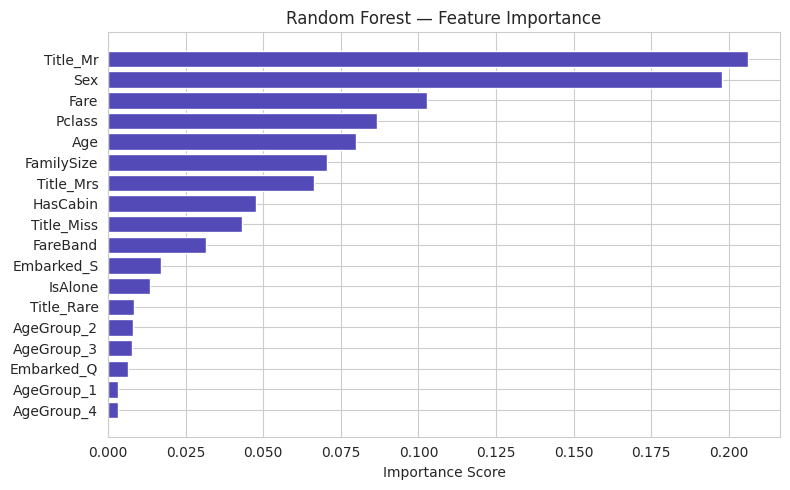

In [147]:
#Step 6 — Understanding what the model learned (feature importance)
import pandas as pd
import matplotlib.pyplot as plt

# Random Forest gives you feature importances for free
feature_names = X_train.columns
importances   = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n=== WHAT RANDOM FOREST FOUND MOST USEFUL ===")
print(feat_df.to_string(index=False))

# Plot it
plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#534AB7')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [148]:
#Step 7 — Make actual predictions
# Predict class labels (0 or 1) for the test set
y_pred = rf.predict(X_test)

# Predict probabilities — more informative than just 0/1
y_prob = rf.predict_proba(X_test)
# Returns [[prob_not_survive, prob_survive], ...]

print("First 5 predictions:", y_pred[:5])
print("First 5 actual values:", y_test.values[:5])

# See probability scores for first 5 passengers
for i in range(5):
    print(f"Passenger {i+1}: "
          f"Predicted={y_pred[i]}, "
          f"Survival probability={y_prob[i][1]*100:.1f}%")

First 5 predictions: [1 0 0 1 1]
First 5 actual values: [1 0 0 1 1]
Passenger 1: Predicted=1, Survival probability=62.5%
Passenger 2: Predicted=0, Survival probability=12.0%
Passenger 3: Predicted=0, Survival probability=14.2%
Passenger 4: Predicted=1, Survival probability=87.9%
Passenger 5: Predicted=1, Survival probability=55.5%


# **Step 6 - Model Evaluation**

Confusion Matrix:
[[92 13]
 [18 56]]


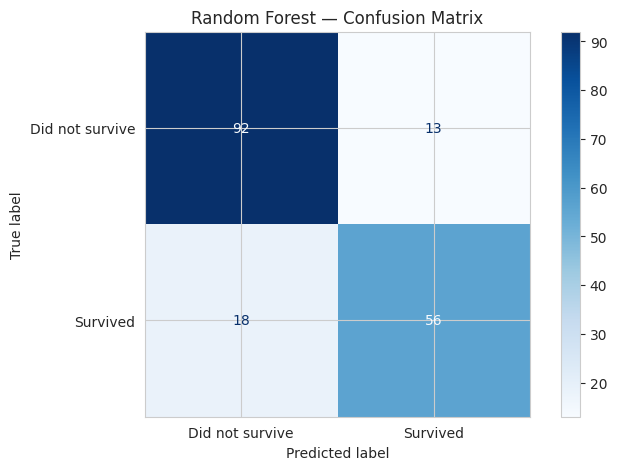


TN=92  FP=13  FN=18  TP=56


In [149]:
#Step 1 — The confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use your best model — Random Forest
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
# [[96  13]    → row 0 = actual NOT survived
#  [15  55]]   → row 1 = actual SURVIVED

# Visual version — much easier to read
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

# Extract individual values
TN, FP, FN, TP = cm.ravel()
print(f"\nTN={TN}  FP={FP}  FN={FN}  TP={TP}")

The confusion matrix is a 2×2 table. Rows = what actually happened. Columns = what the model predicted. The diagonal (top-left to bottom-right) is where the model got it right. Everything off-diagonal is a mistake.

In [150]:
#Step 2 — Precision, Recall, F1 by hand first, then sklearn
#Before running the sklearn function, compute these once manually so the formula is locked in your head:
# Manually compute metrics so you understand the formula
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)
accuracy  = (TP + TN) / (TP + TN + FP + FN)

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

Accuracy  : 82.68%
Precision : 81.16%
Recall    : 75.68%
F1 Score  : 78.32%


In [151]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report)

print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")

Accuracy  : 82.68%
Precision : 81.16%
Recall    : 75.68%
F1 Score  : 78.32%


In [152]:
print("\n=== FULL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
                             target_names=['Did not survive', 'Survived']))


=== FULL CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Did not survive       0.84      0.88      0.86       105
       Survived       0.81      0.76      0.78        74

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



AUC Score: 0.8987


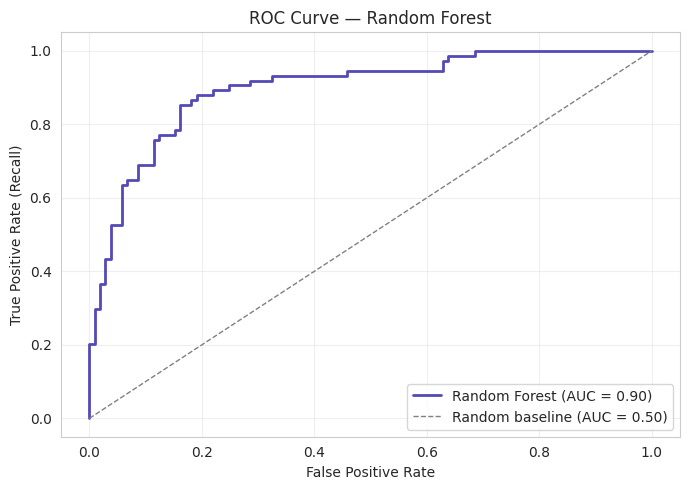

In [153]:
#Step 3 — ROC Curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Get survival probability for each passenger (not just 0/1)
y_prob = rf.predict_proba(X_test)[:, 1]   # column 1 = prob of surviving

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc_score:.4f}")   # ~0.87

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#534AB7', lw=2,
         label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random baseline (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [154]:
#Step 4 — Compare all four models together
from sklearn.metrics import f1_score, roc_auc_score

# Collect all metrics for all models in one place
models_eval = {
    'Logistic Regression': (lr, X_test_scaled),
    'Decision Tree'      : (dt, X_test),
    'Random Forest'      : (rf, X_test),
    'KNN'                : (knn, X_test_scaled),
}

print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 75)

for name, (model, X_data) in models_eval.items():
    preds  = model.predict(X_data)
    probs  = model.predict_proba(X_data)[:, 1]

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, probs)

    print(f"{name:<25} {acc*100:>8.1f}% {prec*100:>9.1f}% "
          f"{rec*100:>7.1f}% {f1*100:>7.1f}% {auc:>8.2f}")

Model                      Accuracy  Precision   Recall       F1      AUC
---------------------------------------------------------------------------
Logistic Regression           82.7%      79.5%    78.4%    78.9%     0.89
Decision Tree                 83.8%      80.8%    79.7%    80.3%     0.87
Random Forest                 82.7%      81.2%    75.7%    78.3%     0.90
KNN                           83.2%      79.7%    79.7%    79.7%     0.88


The analogy that makes it stick permanently — imagine your model is a detective arresting suspects:

Accuracy — of all decisions (arrest/release), how many were right?

Precision — of everyone you arrested, how many were actually guilty?

Recall — of all actual criminals, how many did you catch?

F1 — are you catching criminals without wrongly arresting innocent people?

AUC — how well can you rank "most suspicious" to "least suspicious" overall?

# **The complete mental model of evaluation**
Accuracy  → "Overall, how often was I right?"           Simple but can mislead

Precision → "When I said yes, was I right?"             Trust in positive calls

Recall    → "Of all real yeses, how many did I find?"   Coverage of real cases

F1        → Balance of precision and recall             Best single metric

AUC       → Overall ranking ability across thresholds   Model's raw power

In [155]:
#Step 5 — Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define the grid of hyperparameters to try
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [4, 5, 6, 8],
    'min_samples_split': [2, 5, 10],
}

# GridSearchCV tries every combination + 5-fold cross-validation
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,           # 5-fold cross-validation
    scoring    = 'f1',        # optimise for F1, not just accuracy
    n_jobs     = -1,          # use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_*100:.2f}%")

# Use the best model
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

print(f"\nTest set accuracy after tuning: "
      f"{accuracy_score(y_test, best_preds)*100:.2f}%")
print(f"Test set F1 after tuning: "
      f"{f1_score(y_test, best_preds)*100:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'max_depth': 6, 'min_samples_split': 10, 'n_estimators': 50}
Best CV F1 score: 77.35%

Test set accuracy after tuning: 82.68%
Test set F1 after tuning: 78.32%


GridSearchCV is like hiring an assistant to try every combination of settings for you. If you have 3×4×3 = 36 combinations and 5-fold CV, it trains 180 models and picks the winner. The n_jobs=-1 makes it use all your CPU cores in parallel so it finishes faster.

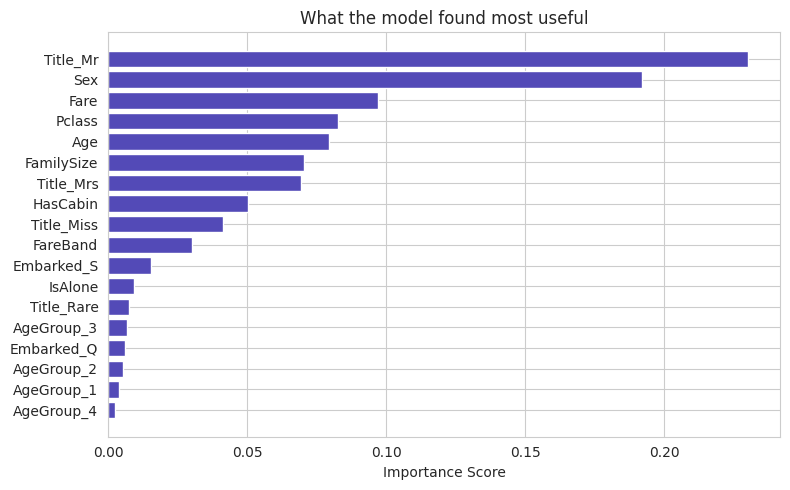

   Feature  Importance
  Title_Mr    0.230068
       Sex    0.191988
      Fare    0.096860
    Pclass    0.082763
       Age    0.079545
FamilySize    0.070368
 Title_Mrs    0.069467
  HasCabin    0.050289
Title_Miss    0.041311
  FareBand    0.030239
Embarked_S    0.015585
   IsAlone    0.009257
Title_Rare    0.007686
AgeGroup_3    0.006737
Embarked_Q    0.005958
AgeGroup_2    0.005222
AgeGroup_1    0.004041
AgeGroup_4    0.002615


In [156]:
#Step 6 — Feature importance (understanding your model)
import pandas as pd

feat_importance = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_importance['Feature'],
         feat_importance['Importance'],
         color='#534AB7')
plt.xlabel('Importance Score')
plt.title('What the model found most useful')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_importance.to_string(index=False))